# Read In, Clean, and Merge Data

## Read in the data

### Read in the gated station entry data

In [1]:
# ALC
# Imports

import pandas as pd 
from os import walk
import re
import seaborn as sns
import matplotlib.pyplot as plt
import datetime
import math

In [2]:
# ALC
# Gated Station Entries
# From the MBTA Open Data Portal
# https://mbta-massdot.opendata.arcgis.com/datasets/001c177f07594e7c99f193dde32284c9_0/explore
input_file_2022 = "../data/gated station entries/GSE_2022.csv"
input_file_2023 = "../data/gated station entries/GSE_2023.csv"
input_file_2024 = "../data/gated station entries/GSE_2024.csv"
input_file_2025 = "../data/gated station entries/GSE_2025.csv"

gse_2022 = pd.read_csv(input_file_2022)
gse_2023 = pd.read_csv(input_file_2023)
gse_2024 = pd.read_csv(input_file_2024)
gse_2025 = pd.read_csv(input_file_2025)

station_entries = pd.concat([gse_2022, gse_2023, gse_2024, gse_2025])

print(station_entries.shape)

(3731053, 7)


### Read in the service alerts data

In [3]:
# ALC
# these are as downloaded from the MBTA's Open Data Portal. There is one file
# for every month of the year. 
# https://mbta-massdot.opendata.arcgis.com/datasets/90ed9092bd7a4285b296d5ff938edf29_0/explore
# https://mbta-massdot.opendata.arcgis.com/datasets/f960d5089e164fb8b6c6936c70719d72/about
# https://mbta-massdot.opendata.arcgis.com/datasets/ef115f7cf6684360b040b6d1d033eff0/about

# todo: use the walk directories function instead of just
# hardcoding all these file names
input_filenames = [[2022, ['alerts_2022_01', 'alerts_2022_02', 'alerts_2022_03', 
                           'alerts_2022_04', 'alerts_2022_05', 'alerts_2022_06', 
                           'alerts_2022_07', 'alerts_2022_08', 'alerts_2022_09', 
                           'alerts_2022_10', 'alerts_2022_11', 'alerts_2022_12']],
                   [2023, ['alerts_2023_01', 'alerts_2023_02', 'alerts_2023_03', 
                           'alerts_2023_04', 'alerts_2023_05', 'alerts_2023_06', 
                           'alerts_2023_07', 'alerts_2023_08', 'alerts_2023_09', 
                           'alerts_2023_10', 'alerts_2023_11', 'alerts_2023_12']],
                   [2024, ['2024-01_ALERTS', '2024-02_ALERTS', '2024-03_ALERTS', 
                           '2024-04_ALERTS', '2024-05_ALERTS', '2024-06_ALERTS', 
                           '2024-07_ALERTS', '2024-08_ALERTS', '2024-09_ALERTS', 
                           '2024-10_ALERTS','2024-11_ALERTS', '2024-12_ALERTS']],
                   [2025, ['2025-01_ALERTS', '2025-02_ALERTS', '2025-03_ALERTS', 
                           '2025-04_ALERTS', '2025-05_ALERTS', '2025-06_ALERTS']]]
# initialize array
alerts = []

for year, filenames in input_filenames:
    for filename in filenames:
        path = f'../data/service alerts/{year}/{filename}.csv'
        # including low_memory = false because we have some nas in columns
        month_alerts = pd.read_csv(path, quotechar='"', low_memory = False)
        alerts.append(month_alerts[month_alerts['effect_detail'] == 'DELAY'])
        
# put it all together
# this is HUGE when you keep every service alert type
service_alerts = pd.concat(alerts)
print(service_alerts.shape)

(792395, 27)


In [4]:
len(service_alerts['alert_id'].unique())

186443

### Read in the speed restrictions data

In [5]:
#ALC
# Speed Restriction Data from MBTA Open Data Portal
# https://mbta-massdot.opendata.arcgis.com/datasets/d73ed67e4cc84a84b818ea2c5caef696/about
slow_zone_files = []
# found this after doing service alerts above
# will focus more on switching to use the api than making consistent for now
for (root, dirs, filenames) in walk("../data/slow zones/"):
    slow_zone_files.extend(filenames)
    break
    
slow_zone_data = []

for file in slow_zone_files:
    path = f"../data/slow zones/{file}"
    if (re.search("\.csv$", file)):
        sz = pd.read_csv(path, quotechar='"')
        slow_zone_data.append(sz)
        
slow_zones = pd.concat(slow_zone_data)
slow_zones.shape

(127922, 32)

### Read in the reliability data

In [6]:
# ALC
# MBTA Reliability data from the MBTA Open Data Portal
# https://mbta-massdot.opendata.arcgis.com/datasets/b3a24561c2104422a78b593e92b566d5_0/explore
reliability_input = "../data/reliability/MBTA Bus, Commuter Rail, & Rapid Transit Reliability.csv"
reliability = pd.read_csv(reliability_input)

reliability.shape

(963838, 13)

## Clean the data and prepare for join

### Make date format consistent

In [7]:
#ALC
def get_date(date):
    return pd.to_datetime(date, format='mixed').dt.date

# the date in the reliability data appears yyyy/mm/dd hh:mm:ss+00
# we will use yyyy-mm-dd for service date
reliability['service_date'] = get_date(reliability['service_date'])

# slow zones uses what we expect but we just rename the column for consistency
slow_zones['Calendar_Date'] = get_date(slow_zones['Calendar_Date'])
slow_zones = slow_zones.rename(columns = {'Calendar_Date': 'service_date'})

# service_alerts is more complicated. there appear to be some problem
# rows. for example in the june 2025 dataset there is a detour alert from july
# of 2024 that never closed
service_alerts['active_period_start_date'] = get_date(service_alerts['active_period_start_date'])
service_alerts['active_period_start_dt'] = get_date(service_alerts['active_period_start_dt'])
service_alerts['active_period_end_dt'] = get_date(service_alerts['active_period_end_dt'])
service_alerts['created_dt'] = get_date(service_alerts['created_dt'])
service_alerts['closed_dt'] = get_date(service_alerts['closed_dt'])
station_entries['service_date'] = get_date(station_entries['service_date'])

### Make line consistent

In [8]:
# ALC
def simplify_route(line):
    if pd.isna(line) or 'Silver Line' in line:
        return None
    elif 'Green Line' in line or 'Green-' in line:
        return 'green'
    elif 'Red Line' in line or 'Red' in line:
        return "red"
    elif 'Blue Line' in line or 'Blue' in line:
        return 'blue'
    elif 'Orange Line' in line or 'Orange' in line:
        return 'orange'
    else:
        return line

# station entry lines
station_entries['route_or_line'] = station_entries['route_or_line'].apply(simplify_route)

# there is silver line data in here which is out of scope
station_entries = station_entries[station_entries['route_or_line'].isin(['green', 'red', 'blue', 'orange'])]
station_entries = station_entries.rename(columns = {'gated_entries': 'est_ridership',
                                                   'route_or_line': 'line'})

# slow zones lines
slow_zones['line'] = slow_zones['Line'].apply(simplify_route)

# reliability lines, cr and rt
reliability['line'] = reliability['gtfs_route_long_name'].apply(simplify_route)

# this removes out of scope bus data
reliability = reliability[reliability['line'].notna()]

service_alerts['route_id'] = service_alerts['route_id'].apply(simplify_route)
service_alerts = service_alerts.rename(columns = {'route_id': 'line'})

### Aggregation

In [9]:
# ALC
# function to aggregate reliability data by date and line
# get one row per line per date with an aggregate score
def agg_reliability_data_daily(reliability):
    return reliability.groupby(['service_date', 'line'], as_index=False)[
        ['otp_numerator', 'otp_denominator']
    ].sum()
    
# gated station entries are given by the half hour. we will need to
# aggregate these down to the day
def agg_station_entries_daily(station_entries):
    return station_entries.groupby(['service_date', 'line'], as_index=False)[
               'est_ridership'
           ].sum()

# count and distane of slow zones daily
def agg_slow_zones_daily(slow_zones):
    return slow_zones.groupby(['service_date', 'line'], as_index=False).agg(
        num_slow_zones = ('ID', 'nunique'),
        total_track_pct = ('Line_Restricted_Track_Pct', 'sum'),
        total_miles_affected = ('Restriction_Distance_Miles', 'sum')
    )

## Relate the data

In [10]:
# ALC
# join datasets
# does it have to be done two at a time?
station_entries_reliability = pd.merge(
    agg_station_entries_daily(station_entries), 
    agg_reliability_data_daily(reliability), 
    on = ['service_date', 'line'], 
    how = 'inner')
    
# doing a left join here. if there is no data in the 
# slow zones file, it means slow zones = none
merged_data = pd.merge(
    station_entries_reliability,
    agg_slow_zones_daily(slow_zones),
    on = ['service_date', 'line'],
    how = 'left'
)

merged_data = merged_data[merged_data['service_date'] > datetime.date(2022, 12, 31)]

In [11]:
# JJ
# Expand service alerts and prep columns

service_alerts['active_period_start_dt'] = pd.to_datetime(service_alerts['active_period_start_dt']).dt.date
service_alerts['active_period_end_dt'] = pd.to_datetime(service_alerts['active_period_end_dt']).dt.date

service_alerts['line'] = service_alerts['line'].astype(str).apply(simplify_route)
service_alerts = service_alerts[service_alerts['line'].isin(['red', 'blue', 'green', 'orange'])]

In [12]:
# JJ
# Deduplicate alerts by alert_id first
service_alerts = service_alerts.drop_duplicates(subset=["alert_id"])

In [13]:
# JJ
# Expand alerts by date

expanded_alerts = []
for _, row in service_alerts.iterrows():
    if pd.isna(row['active_period_start_dt']) or pd.isna(row['active_period_end_dt']):
        continue
    for d in pd.date_range(row['active_period_start_dt'], row['active_period_end_dt']):
        expanded_alerts.append({
            'service_date': d.date(),
            'line': row['line']
        })

expanded_alerts_df = pd.DataFrame(expanded_alerts)

In [14]:
# JJ
# Aggregate counts

daily_alert_counts = (
    expanded_alerts_df
    .groupby(['service_date', 'line'], as_index=False)
    .size()
    .rename(columns={'size': 'num_alerts'})
)

In [15]:
# ALC
merged_data['otp_score'] = merged_data['otp_numerator'] / merged_data['otp_denominator']
merged_data['num_slow_zones']

# if data is not present it means there were no slow zones
merged_data['num_slow_zones'] = merged_data['num_slow_zones'].fillna(0)
merged_data['total_track_pct'] = merged_data['total_track_pct'].fillna(0)
merged_data['total_miles_affected'] = merged_data['total_miles_affected'].fillna(0)
# these may be useful
merged_data['day_of_week'] = pd.to_datetime(merged_data['service_date']).dt.day_name()
merged_data['month'] = pd.to_datetime(merged_data['service_date']).dt.month_name()
# ideas to add: mark federal holidays, special event days, periods of known
# entire line closures, etc

merged_data

,service_date,line,est_ridership,otp_numerator,otp_denominator,num_slow_zones,total_track_pct,total_miles_affected,otp_score,day_of_week,month
1430,2023-01-01,blue,15214.400000,33536.796260,33747.309640,0.0,0.000000,0.000000,0.993762,Sunday,January
1431,2023-01-01,green,22745.689929,46343.320825,58270.108870,17.0,0.032971,1.780114,0.795319,Sunday,January
1432,2023-01-01,orange,24492.170000,45674.325060,46679.887020,12.0,0.088899,2.003788,0.978458,Sunday,January
1433,2023-01-01,red,27863.440000,59984.367440,66606.054480,23.0,0.074641,3.538731,0.900584,Sunday,January
1434,2023-01-02,blue,19025.400000,67706.968410,68626.254520,0.0,0.000000,0.000000,0.986604,Monday,January
...,...,...,...,...,...,...,...,...,...,...,...
3481,2024-05-27,red,40922.660000,217481.829108,237909.677076,44.0,0.153800,7.291667,0.914136,Monday,May
3482,2024-05-28,blue,38104.400000,61254.191904,65380.812269,0.0,0.000000,0.000000,0.936883,Tuesday,May
3483,2024-05-28,green,43661.060004,85051.910693,107692.471183,9.0,0.015805,0.853333,0.789767,Tuesday,May
3484,2024-05-28,orange,35067.860000,17439.572483,20056.907421,35.0,0.185100,4.172159,0.869505,Tuesday,May


In [16]:
# JJ
# Merge with merged data

final_data_v2 = pd.merge(
    merged_data,
    daily_alert_counts,
    on=["service_date", "line"],
    how="left"
)

final_data_v2.head(5)

,service_date,line,est_ridership,otp_numerator,otp_denominator,num_slow_zones,total_track_pct,total_miles_affected,otp_score,day_of_week,month,num_alerts
0,2023-01-01,blue,15214.400000,33536.796260,33747.30964,0.0,0.000000,0.000000,0.993762,Sunday,January,NaN
1,2023-01-01,green,22745.689929,46343.320825,58270.10887,17.0,0.032971,1.780114,0.795319,Sunday,January,NaN
2,2023-01-01,orange,24492.170000,45674.325060,46679.88702,12.0,0.088899,2.003788,0.978458,Sunday,January,1.0
3,2023-01-01,red,27863.440000,59984.367440,66606.05448,23.0,0.074641,3.538731,0.900584,Sunday,January,NaN
4,2023-01-02,blue,19025.400000,67706.968410,68626.25452,0.0,0.000000,0.000000,0.986604,Monday,January,NaN


In [17]:
# ALC
# lack of service alerts, fill with 0
final_data_v2['num_alerts'] = final_data_v2['num_alerts'].fillna(0)


In [18]:
# ALC
final_data_v2.corr(numeric_only = True)

,est_ridership,otp_numerator,otp_denominator,num_slow_zones,total_track_pct,total_miles_affected,otp_score,num_alerts
est_ridership,1.000000,0.882259,0.879146,0.421414,-0.097568,0.274147,0.113591,0.131640
otp_numerator,0.882259,1.000000,0.991069,0.408791,-0.096116,0.278422,0.159983,0.126244
otp_denominator,0.879146,0.991069,1.000000,0.442134,-0.114473,0.316778,0.043726,0.165073
num_slow_zones,0.421414,0.408791,0.442134,1.000000,0.137445,0.923036,-0.245081,0.182643
total_track_pct,-0.097568,-0.096116,-0.114473,0.137445,1.000000,0.397312,0.159315,-0.126781
total_miles_affected,0.274147,0.278422,0.316778,0.923036,0.397312,1.000000,-0.299245,0.179104
otp_score,0.113591,0.159983,0.043726,-0.245081,0.159315,-0.299245,1.000000,-0.304039
num_alerts,0.131640,0.126244,0.165073,0.182643,-0.126781,0.179104,-0.304039,1.000000


In [19]:
# get some summary statistics for our numeric columns
pd.set_option('display.max_columns', None)
for x in ['est_ridership', 'otp_numerator', 'otp_denominator', 
        'num_slow_zones', 'total_track_pct', 'total_miles_affected', 
        'otp_score', 'num_alerts']:
    print(x)
    print(final_data_v2[x].describe())
    print(final_data_v2[x].skew())
    print(final_data_v2[x].kurt())

est_ridership
count      2056.000000
mean      53453.791443
std       23868.360808
min        2488.590000
25%       35146.850000
50%       47540.791585
75%       76209.985000
max      129547.140000
Name: est_ridership, dtype: float64
0.3552517302896341
-0.9381528261964682
otp_numerator
count      2056.000000
mean     102204.269171
std       63388.560169
min        2064.732243
25%       55900.676911
50%       77875.323140
75%      153640.427895
max      242134.141000
Name: otp_numerator, dtype: float64
0.6402318300861335
-0.8373657680334823
otp_denominator
count      2056.000000
mean     114958.678262
std       69326.808345
min        2422.118930
25%       62283.311907
50%       94781.146781
75%      162939.945938
max      250680.316100
Name: otp_denominator, dtype: float64
0.5711986827377088
-0.8518771624017143
num_slow_zones
count    2056.000000
mean       41.697471
std        29.552854
min         0.000000
25%        16.000000
50%        35.000000
75%        63.000000
max       116.0

In [20]:
# get some proportions and frequencies for our categorical variables
for line in final_data_v2['line'].unique():
    print(line + " appears " + str(len(final_data_v2[final_data_v2['line'] == line])) 
          + " times")
    print(line + " appears " + str(len(final_data_v2[final_data_v2['line'] == line])/len(final_data_v2) * 100)
          + " % of the time")
    
    
for line in final_data_v2['day_of_week'].unique():
    print(line + " appears " + str(len(final_data_v2[final_data_v2['day_of_week'] == line])) 
          + " times")
    print(line + " appears " + str(len(final_data_v2[final_data_v2['day_of_week'] == line])/len(final_data_v2) * 100)
          + " % of the time")
    
for line in final_data_v2['month'].unique():
    print(line + " appears " + str(len(final_data_v2[final_data_v2['month'] == line])) 
          + " times")
    print(line + " appears " + str(len(final_data_v2[final_data_v2['month'] == line])/len(final_data_v2) * 100)
          + " % of the time")

blue appears 514 times
blue appears 25.0 % of the time
green appears 514 times
green appears 25.0 % of the time
orange appears 514 times
orange appears 25.0 % of the time
red appears 514 times
red appears 25.0 % of the time
Sunday appears 296 times
Sunday appears 14.396887159533073 % of the time
Monday appears 296 times
Monday appears 14.396887159533073 % of the time
Tuesday appears 296 times
Tuesday appears 14.396887159533073 % of the time
Wednesday appears 292 times
Wednesday appears 14.202334630350194 % of the time
Thursday appears 292 times
Thursday appears 14.202334630350194 % of the time
Friday appears 292 times
Friday appears 14.202334630350194 % of the time
Saturday appears 292 times
Saturday appears 14.202334630350194 % of the time
January appears 248 times
January appears 12.062256809338521 % of the time
February appears 228 times
February appears 11.089494163424124 % of the time
March appears 248 times
March appears 12.062256809338521 % of the time
April appears 240 times
Ap

In [24]:
# JJ
# save to CSV
final_data_v2.to_csv("../data/final_merged_data_v2.csv", index=False)

In [25]:
# JJ
# Check service alert count per line
service_alerts['line'].value_counts(dropna=False)

line
green     1478
red       1448
orange     781
blue       654
Name: count, dtype: int64

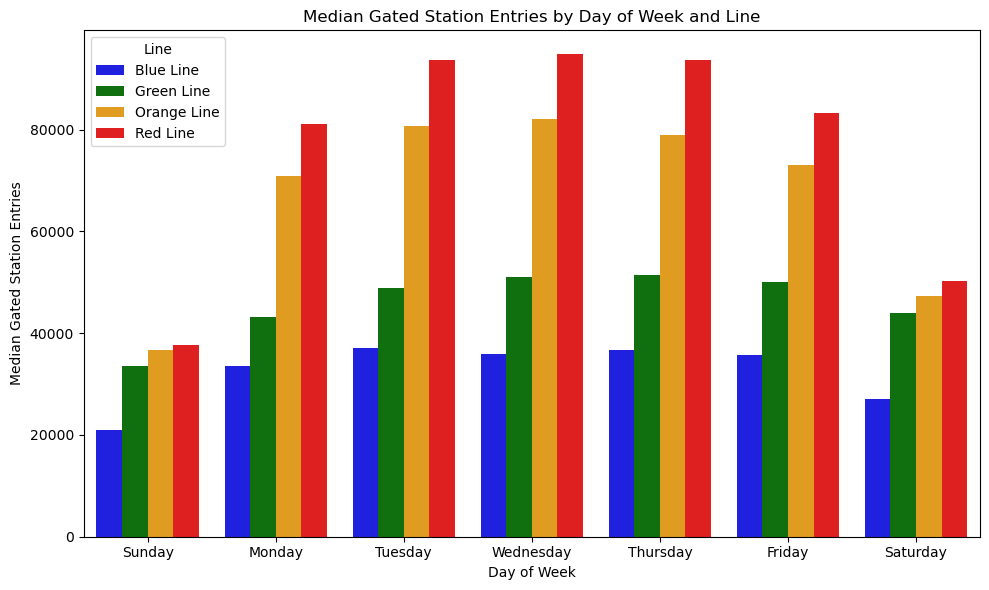

In [21]:
# 1st plot, show how day of the week may be something we need
# to handle
plt.figure(figsize = (10, 6))

# have colors match line
palette = {'green': 'green', 'blue': 'blue', 'orange': 'orange', 'red': 'red'}

sns.barplot(
    data = merged_data,
    x = 'day_of_week',
    y = 'est_ridership',
    hue = 'line',
    estimator = 'median',
    errorbar = None,
    palette = palette
)

# labels
plt.title('Median Gated Station Entries by Day of Week and Line')
plt.ylabel('Median Gated Station Entries')
plt.xlabel('Day of Week')
# make better labels
plt.legend(title = 'Line', 
           labels = ['Blue Line', 'Green Line', 'Orange Line', 'Red Line'])
plt.tight_layout()
plt.palette = palette
plt.show()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


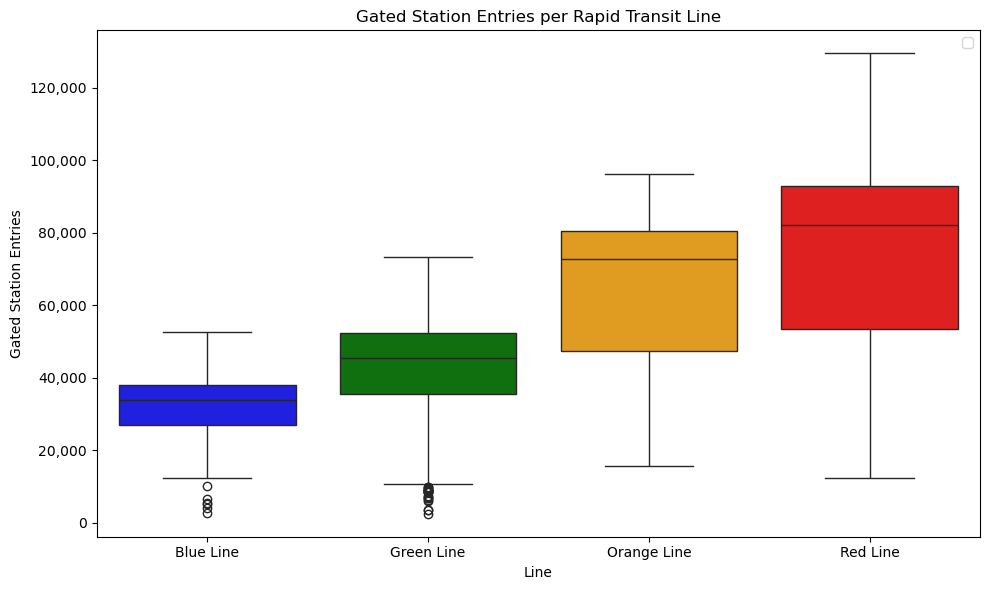

In [22]:
# we'll need to look at train lines individually
plt.figure(figsize = (10, 6))

# have colors match line
palette = {'green': 'green', 'blue': 'blue', 'orange': 'orange', 'red': 'red'}

sns.boxplot(x = 'line', 
            y = 'est_ridership',
            hue = 'line',
            palette = palette,
            data = merged_data)

lines = ['Blue Line', 'Green Line', 'Orange Line', 'Red Line']
# labels
plt.title('Gated Station Entries per Rapid Transit Line')
plt.xlabel('Line')
plt.ylabel('Gated Station Entries')
plt.gca().yaxis.set_major_formatter(lambda x, pos: f'{x:,.0f}')
plt.xticks(ticks = [0, 1, 2, 3], labels = lines)
# make better labels
plt.legend()
plt.tight_layout()
plt.palette = palette
plt.show()

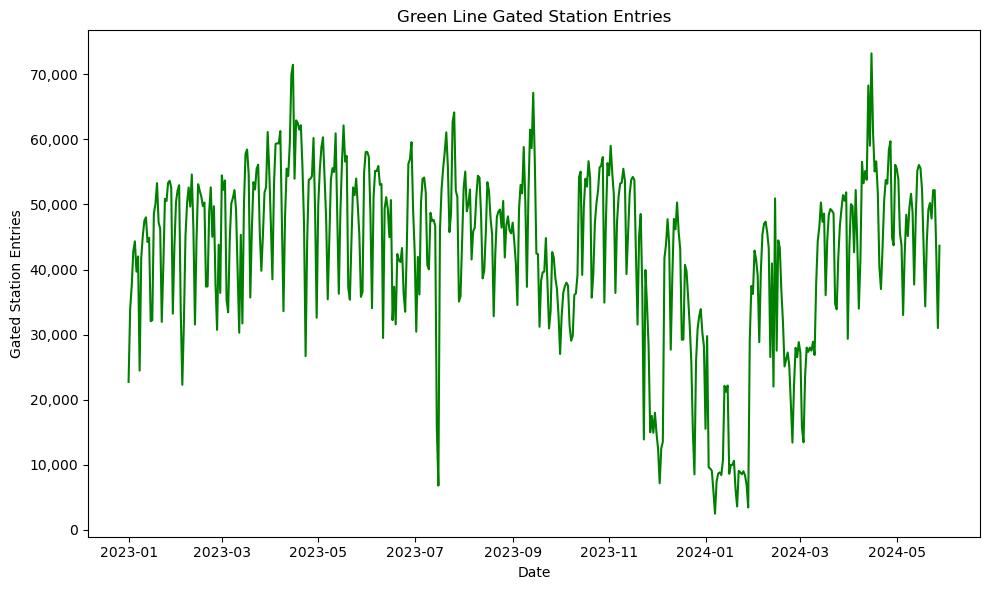

In [23]:
plt.figure(figsize = (10, 6))

sns.lineplot(x = 'service_date', 
            y = 'est_ridership',
             color = 'green',
            data = merged_data[merged_data['line'] == 'green'])
# labels
plt.title('Green Line Gated Station Entries')
plt.xlabel('Date')
plt.ylabel('Gated Station Entries')
plt.gca().yaxis.set_major_formatter(lambda x, pos: f'{x:,.0f}')
plt.tight_layout()
plt.show()